In [3]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
import time

u = unit(coerce_to_integer=True)

2026-06-23 00:48:59,593 - qm - INFO     - Starting session: d876072a-9a21-464a-abb6-c891927776c8


In [5]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.24 * u.us,
    pulse_amplitude=0.47,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=144.4,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=17950 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "floquet_expt"
)

cfg = qnmr.cfg_from_settings(settings)

In [ ]:
def plotcases(cases, t0) :
    def stretched_exp(x, A, tau, beta):
        return A* np.exp(-(x / tau) ** beta)

    all_taus = []
    all_cases = []

    fig, ax = plt.subplots(figsize=(10, 6))

    for case, exp_id in cases.items():
        data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
        if not data_path.exists():
            print(f"Warning: missing {data_path}, skipping")
            continue

        with open(data_path, "r") as f:
            data_dict = json.load(f)

        re = np.array(data_dict["I_data"]) * 1e6
        periods = np.array(data_dict["sweep_axis"])
        signal = re[:, 0]/re[0,0]

        time = periods * (24 * t0)
        mask = signal > 0
        x, y = time[mask], signal[mask]
        if len(x) < 3:
            print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
            continue

        popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.3], maxfev=10000)
        amplitude_fit, tau_fit, beta_fit = popt
        all_taus.append(tau_fit)
        all_cases.append(case)

        x_fit = np.linspace(min(time), max(time), 500)
        y_fit = stretched_exp(x_fit, *popt)

        ax.scatter(time, signal, s=20, alpha=0.7)
        # ax.errorbar(time, signal, yerr=(70/re[0,0]), fmt='o')
        ax.plot(x_fit, y_fit, linewidth=1.8,
                label=f"{case} (τ={tau_fit:.1f}μs)")
        print(*popt)

    ax.set_title("Floquet decay curves for time suspension")
    ax.set_xlabel("Time (μs)")
    ax.set_ylabel("Raw signal")
    ax.legend(loc="upper right", fontsize="small", ncol=2)
    ax.grid(True)

    # fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
    # ax_tau.bar(all_cases, all_taus)
    # ax_tau.set_title("Fitted decay time τ vs. type")
    # ax_tau.tick_params(axis='x', labelrotation=70)
    # ax_tau.set_ylabel("T1 (μs)")
    # ax_tau.grid(True)

    print("Completed fitting experiments:")
    for case, tau in zip(all_cases, all_taus):
        print(f"case={case} -> tau={tau:.3f}μs")

1.0159060945542489 3201.283816246306 0.7660826303034921
1.012738821919736 3382.1069543570047 0.7507817360804857
1.0103458250022344 3541.0164872661167 0.7298580079335245
1.0112972605835673 3578.2926764957383 0.7166825998686179
Completed fitting experiments:
case=5us -> tau=3201.284μs
case=Opt ErrJ0 -> tau=3382.107μs
case=Opt CorrectedJ0 -> tau=3541.016μs
case=Opt FinitePulse -> tau=3578.293μs


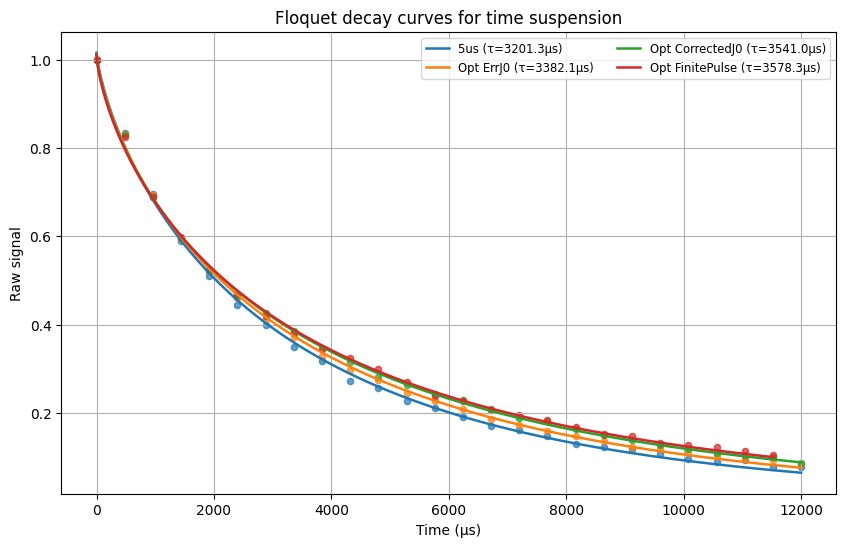

In [34]:
cases = {
    "5us": 47,
    "Opt ErrJ0": 48,
    "Opt CorrectedJ0": 49,
    "Opt FinitePulse": 78,
}
plotcases(cases, t0=5)

1.0131025531063265 3350.8554975494003 0.7461045878171897
1.00546784111468 2839.924138241472 0.8233367477250139
1.0034408835178528 3239.513282394605 0.7983282667576787
1.0112972605835673 3578.2926764957383 0.7166825998686179
1.0091741517195643 3477.4177262357966 0.7026146757012636
1.0068912528488534 3485.2211463348162 0.7348830508957037
Completed fitting experiments:
case=Unopt -> tau=3350.855μs
case=Opt Finite, NN2, min_blk -> tau=2839.924μs
case=Opt Finite, NN2, min_fid -> tau=3239.513μs
case=Opt Finite, NN0, min_fid -> tau=3578.293μs
case=Opt Finite, NN1, min_fid -> tau=3477.418μs
case=Opt Finite, NN1, min_blk -> tau=3485.221μs


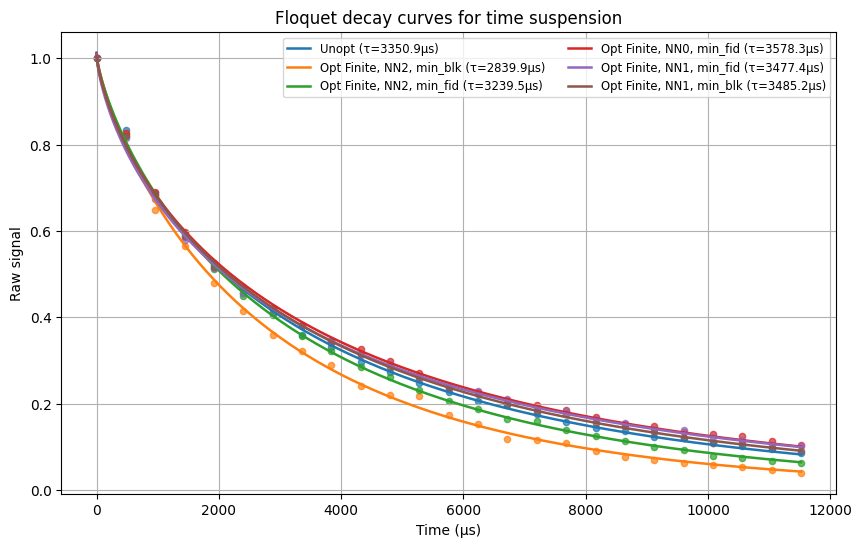

In [35]:
cases = {
    "Unopt": 84,
    "Opt Finite, NN2, min_blk" : 79,
    "Opt Finite, NN2, min_fid" : 82,
    "Opt Finite, NN0, min_fid": 78,
    "Opt Finite, NN1, min_fid": 86,
    "Opt Finite, NN1, min_blk": 87,
}
plotcases(cases, t0=5)

1.0129137028489106 1733.7370887233612 0.7987474650314415
1.0104706517361193 1817.0036425779515 0.7636805805305489
Completed fitting experiments:
case=Unopt -> tau=1733.737μs
case=Opt Finite, NN0, min_fid -> tau=1817.004μs


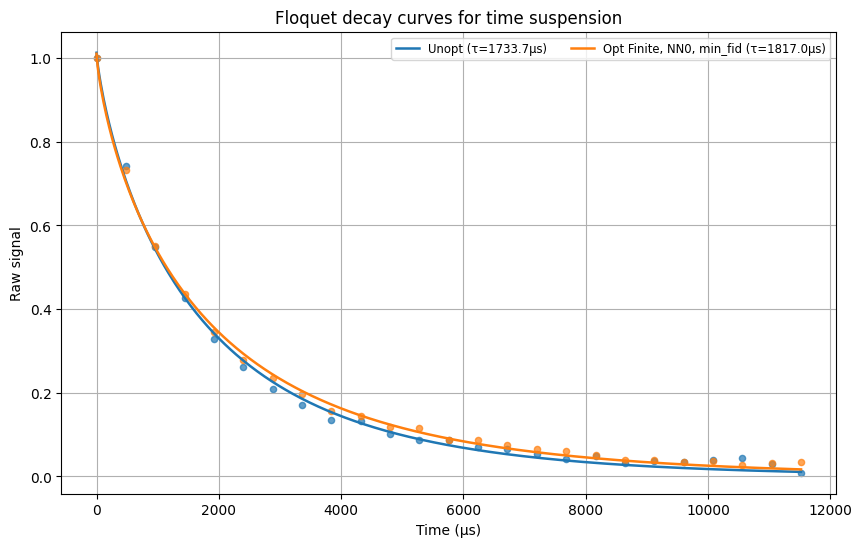

In [ ]:
# case = ("15μs", "Opt Old", "Opt Energy"); experiment_ids = (58,57,56); t0 = 15
# case = ("10us", "Opt Old", "Opt Energy"); experiment_ids = (53,54,55); t0 = 10



# cases = {
#     "Unopt": 89,
#     "Opt Finite, NN0, min_fid": 88,
#     "Opt Alternate":91,
# }; t0=5
# cases = {
#     "Unopt": 101, #flip w 102
#     "Opt Finite, NN0, min_fid": 93,
#     "Opt Infinite, NN0, min_fid": 102
# }; t0=4
# cases = {
#     "Unopt": 96,
#     "Opt Finite, NN0, min_fid": 95,
# }; t0=6
cases = {
    "Unopt": 98, #103
    "Opt Finite, NN0, min_fid": 104, #97
}; t0=7

plotcases(cases, t0=5)

1.0105543547069253 3226.8636426366165 0.7766289472726586
1.0082781668400052 1889.2169627356252 0.735964106549649
1.0167923744321552 3438.1137426360438 0.7307731568859018
1.0106321133027896 3079.284794008002 0.8891079956670057
0.9985603339362321 2783.4086230632597 0.8756121430691117
Completed fitting experiments:
case=Unopt -> tau=3226.864μs
case=Opt Periodic, N5 NN1, min_fid -> tau=1889.217μs
case=Opt Periodic, N5 NN1, min_blk -> tau=3438.114μs
case=Opt Periodic, N7 NN2, min_fid -> tau=3079.285μs
case=Opt Periodic, N7 NN2, min_blk -> tau=2783.409μs


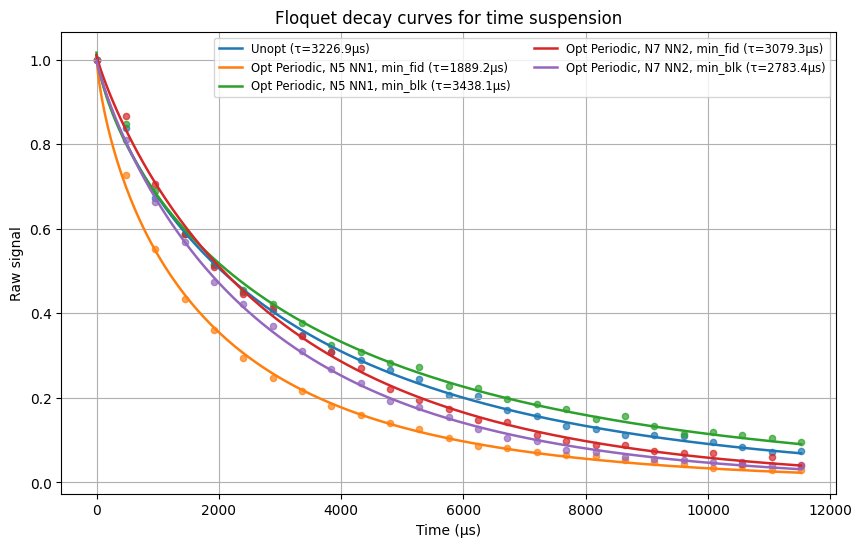

In [60]:
cases = {
    "Unopt": 111,
    "Opt Periodic, N5 NN1, min_fid": 105,
    "Opt Periodic, N5 NN1, min_blk": 106,
    "Opt Periodic, N7 NN2, min_fid": 107,
    "Opt Periodic, N7 NN2, min_blk": 108,
};
plotcases(cases, t0=5)